<a href="https://colab.research.google.com/github/Sarakazemi-prog/AIHC5020/blob/main/finalexam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem 1: Summarizing Data Types in Python

In [43]:
import pandas as pd

# Define the data for the DataFrame
data = [
    {
        'name': 'Integer',
        'python_symbol': 'int',
        'example': str(25),
        'falsy_value': str(0),
        'usage': 'Represents whole numbers'
    },
    {
        'name': 'Float',
        'python_symbol': 'float',
        'example': str(25.5),
        'falsy_value': str(0.0),
        'usage': 'Represents real numbers with decimal points'
    },
    {
        'name': 'Boolean',
        'python_symbol': 'bool',
        'example': str(True),
        'falsy_value': str(False),
        'usage': 'Represents truth values (True or False)'
    },
    {
        'name': 'String',
        'python_symbol': 'str',
        'example': "'hello'",
        'falsy_value': "''",
        'usage': 'Represents sequences of characters'
    },
    {
        'name': 'NoneType',
        'python_symbol': 'NoneType',
        'example': str(None),
        'falsy_value': str(None),
        'usage': 'Represents the absence of a value'
    },
    {
        'name': 'Complex',
        'python_symbol': 'complex',
        'example': str(complex(1, 2)),
        'falsy_value': str(complex(0, 0)),
        'usage': 'Represents numbers with real and imaginary parts'
    },
    {
        'name': 'List',
        'python_symbol': 'list',
        'example': str([1, 2, 3]),
        'falsy_value': str([]),
        'usage': 'Ordered, mutable collection of items'
    },
    {
        'name': 'Tuple',
        'python_symbol': 'tuple',
        'example': str((1, 2, 3)),
        'falsy_value': str(()),
        'usage': 'Ordered, immutable collection of items'
    },
    {
        'name': 'Dictionary',
        'python_symbol': 'dict',
        'example': str({'a': 1, 'b': 2}),
        'falsy_value': str({}),
        'usage': 'Unordered, mutable collection of key-value pairs'
    }
]

# Create the DataFrame
data_types_df = pd.DataFrame(data)

# Display the DataFrame
display(data_types_df)


,name,python_symbol,example,falsy_value,usage
0,Integer,int,25,0,Represents whole numbers
1,Float,float,25.5,0.0,Represents real numbers with decimal points
2,Boolean,bool,True,False,Represents truth values (True or False)
3,String,str,'hello','',Represents sequences of characters
4,NoneType,NoneType,None,None,Represents the absence of a value
5,Complex,complex,(1+2j),0j,Represents numbers with real and imaginary parts
6,List,list,"[1, 2, 3]",[],"Ordered, mutable collection of items"
7,Tuple,tuple,"(1, 2, 3)",(),"Ordered, immutable collection of items"
8,Dictionary,dict,"{'a': 1, 'b': 2}",{},"Unordered, mutable collection of key-value pairs"


In [44]:
#problem-2

## Problem 2: Chat Log Data

In [45]:
import pandas as pd
from google.cloud import storage
import json

def load_chat_log_data(chat_id):
    """
    Loads a chat log from Google Cloud Storage, processes it, and returns a DataFrame.

    Args:
        chat_id (int): The integer ID of the chat log to load.

    Returns:
        pd.DataFrame or None: A DataFrame representing the chat log with human-readable timestamps,
                              or None if the file is not found.
    """
    # Instantiate an anonymous client to access public buckets
    client = storage.Client.create_anonymous_client()
    bucket = client.get_bucket('cloud-samples-data')

    # Correcting blob_name to match actual file format: chat_{id}.json
    blob_name = f'ccai/sample-chat-logs/chat_{chat_id}.json'
    blob = bucket.blob(blob_name)

    if not blob.exists():
        print(f"No chat log file found for ID: {chat_id}")
        return None

    try:
        # Download the blob content as a string
        json_data = blob.download_as_string()
        # Parse the JSON string
        chat_content = json.loads(json_data)

        # The actual chat messages are under the 'entries' key
        chat_messages = chat_content.get('entries', [])

        # Convert to DataFrame
        df = pd.DataFrame(chat_messages)

        # The timestamp key is 'start_timestamp_usec', not 'timestamp'
        if 'start_timestamp_usec' in df.columns:
            df['timestamp'] = pd.to_datetime(df['start_timestamp_usec'], unit='us')
            # Drop the original 'start_timestamp_usec' column after converting to 'timestamp'
            df = df.drop(columns=['start_timestamp_usec'])
        else:
            raise KeyError("Key 'start_timestamp_usec' not found in chat messages.")

        # Format the timestamp to YYYY-mm-dd HH:MM:SS
        df['timestamp'] = df['timestamp'].dt.strftime('%Y-%m-%d %H:%M:%S')

        return df

    except Exception as e:
        print(f"Error processing chat log ID {chat_id}: {e}")
        return None

In [46]:
# Call the function for chat log with ID 101
chat_log_101_df = load_chat_log_data(101)

# Display the resulting DataFrame if it exists
if chat_log_101_df is not None:
    display(chat_log_101_df.head())
    print(f"\nFull DataFrame info for chat log ID 101:")
    chat_log_101_df.info()

,text,role,user_id,timestamp
0,"Hello, how can I assist you today?",AGENT,2,2023-02-23 02:07:40
1,"Hi, I'm having an issue with my laptop",CUSTOMER,1,2023-02-23 02:07:58
2,Sorry to hear. Can you tell me what the proble...,AGENT,2,2023-02-23 02:08:16
3,The laptop is not connecting to the internet. ...,CUSTOMER,1,2023-02-23 02:08:34
4,Can you give me more details about the problem...,AGENT,2,2023-02-23 02:08:52



Full DataFrame info for chat log ID 101:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       14 non-null     object
 1   role       14 non-null     object
 2   user_id    14 non-null     int64 
 3   timestamp  14 non-null     object
dtypes: int64(1), object(3)
memory usage: 580.0+ bytes


#problem3

## Problem 3: Chest X-ray DICOM manifest

In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
!pip install -q pydicom

In [49]:
import os
import pandas as pd
import pydicom


def create_dicom_manifest(dicom_folder_path):
    """
    Generates a manifest DataFrame for DICOM files.

    Each row represents one DICOM series and contains:
    series UID, study UID, patient ID, study date,
    modality, number of images, and series directory.
    """

    series_info = {}

    # Make sure folder exists
    if not os.path.exists(dicom_folder_path):
        print(f"ERROR: Folder does not exist: {dicom_folder_path}")
        return pd.DataFrame()

    # Go through all files and subfolders
    for root, dirs, files in os.walk(dicom_folder_path):

        for file_name in files:

            # Ignore hidden files
            if file_name.startswith('.'):
                continue

            file_path = os.path.join(root, file_name)

            try:
                # Read DICOM metadata only
                ds = pydicom.dcmread(
                    file_path,
                    stop_before_pixels=True
                )

                # Get SeriesInstanceUID
                series_uid = getattr(ds, 'SeriesInstanceUID', None)

                # Skip if SeriesInstanceUID is missing
                if series_uid is None:
                    continue

                series_uid = str(series_uid)

                # Add new series
                if series_uid not in series_info:

                    series_info[series_uid] = {
                        'series UID': series_uid,

                        'study UID': str(
                            getattr(ds, 'StudyInstanceUID', 'N/A')
                        ),

                        'patient ID': str(
                            getattr(ds, 'PatientID', 'N/A')
                        ),

                        'study date': str(
                            getattr(ds, 'StudyDate', 'N/A')
                        ),

                        'modality': str(
                            getattr(ds, 'Modality', 'N/A')
                        ),

                        'number of images': 0,

                        'series directory': root
                    }

                # Count image
                series_info[series_uid]['number of images'] += 1

            except Exception as e:
                # Skip files that are not valid DICOM files
                continue

    # Convert dictionary to DataFrame
    manifest_data = list(series_info.values())

    df = pd.DataFrame(manifest_data)

    return df

In [50]:
dicom_folder_path = '/content/drive/MyDrive/AIHC5020/dicom/chest_xray'

dicom_manifest_df = create_dicom_manifest(dicom_folder_path)

dicom_manifest_df.head()

,series UID,study UID,patient ID,study date,modality,number of images,series directory
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.140111454550...,1.3.6.1.4.1.14519.5.2.1.6279.6001.213083367261...,LIDC-IDRI-0015,20000101,DX,1,/content/drive/MyDrive/AIHC5020/dicom/chest_xr...
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.541650212189...,1.3.6.1.4.1.14519.5.2.1.6279.6001.675114969651...,LIDC-IDRI-0023,20000101,DX,2,/content/drive/MyDrive/AIHC5020/dicom/chest_xr...
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.334422875695...,1.3.6.1.4.1.14519.5.2.1.6279.6001.302822025885...,LIDC-IDRI-0040,20000101,DX,2,/content/drive/MyDrive/AIHC5020/dicom/chest_xr...
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.140614242738...,1.3.6.1.4.1.14519.5.2.1.6279.6001.269469709045...,LIDC-IDRI-0014,20000101,DX,2,/content/drive/MyDrive/AIHC5020/dicom/chest_xr...
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.239368516910...,1.3.6.1.4.1.14519.5.2.1.6279.6001.333103030188...,LIDC-IDRI-0012,20000101,DX,2,/content/drive/MyDrive/AIHC5020/dicom/chest_xr...


#Problem 4

In [51]:
import os
import pydicom
import matplotlib.pyplot as plt
import numpy as np


def visualize_patient_xrays(patient_id, manifest_df):
    """
    Visualize all DICOM instances associated with a specified patient.

    Parameters
    ----------
    patient_id : str
        Patient ID to visualize.

    manifest_df : pandas.DataFrame
        Manifest DataFrame created in Problem 3.

    Returns
    -------
    None
        Displays the DICOM images using matplotlib.
    """

    # Filter the manifest for the specified patient
    patient_rows = manifest_df[
        manifest_df['patient ID'].astype(str) == str(patient_id)
    ]

    # If patient is not found
    if patient_rows.empty:
        print(f"Patient '{patient_id}' was not found in the manifest.")
        return None

    dicom_files = []

    # Go through every series belonging to this patient
    for _, row in patient_rows.iterrows():

        series_directory = row['series directory']
        series_uid = str(row['series UID'])

        # Search files in the series directory
        for file_name in os.listdir(series_directory):

            if file_name.startswith('.'):
                continue

            file_path = os.path.join(series_directory, file_name)

            # Ignore directories
            if not os.path.isfile(file_path):
                continue

            try:
                ds = pydicom.dcmread(file_path)

                # Make sure the file belongs to this series
                if str(getattr(ds, 'SeriesInstanceUID', '')) == series_uid:
                    dicom_files.append((file_path, ds))

            except Exception:
                continue

    # If no readable DICOM instances were found
    if len(dicom_files) == 0:
        print(f"No readable DICOM instances were found for patient '{patient_id}'.")
        return None

    # Sort images by InstanceNumber if available
    dicom_files.sort(
        key=lambda x: int(getattr(x[1], 'InstanceNumber', 0))
    )

    num_images = len(dicom_files)

    # Decide layout automatically
    if num_images == 1:
        fig, ax = plt.subplots(figsize=(8, 8))

        ds = dicom_files[0][1]

        ax.imshow(ds.pixel_array, cmap='gray')
        ax.set_title(
            f"Patient: {patient_id}\n"
            f"Instance: {getattr(ds, 'InstanceNumber', 1)}"
        )
        ax.axis('off')

    else:
        # Use up to 4 images per row
        cols = min(4, num_images)
        rows = int(np.ceil(num_images / cols))

        fig, axes = plt.subplots(
            rows,
            cols,
            figsize=(5 * cols, 5 * rows)
        )

        # Make axes easy to iterate through
        axes = np.array(axes).reshape(-1)

        for ax, (_, ds) in zip(axes, dicom_files):

            ax.imshow(ds.pixel_array, cmap='gray')

            ax.set_title(
                f"Instance {getattr(ds, 'InstanceNumber', 'N/A')}"
            )

            ax.axis('off')

        # Hide unused axes
        for ax in axes[num_images:]:
            ax.axis('off')

    plt.suptitle(
        f"Chest X-rays for Patient {patient_id}",
        fontsize=16
    )

    plt.tight_layout()

    plt.show()

    return None

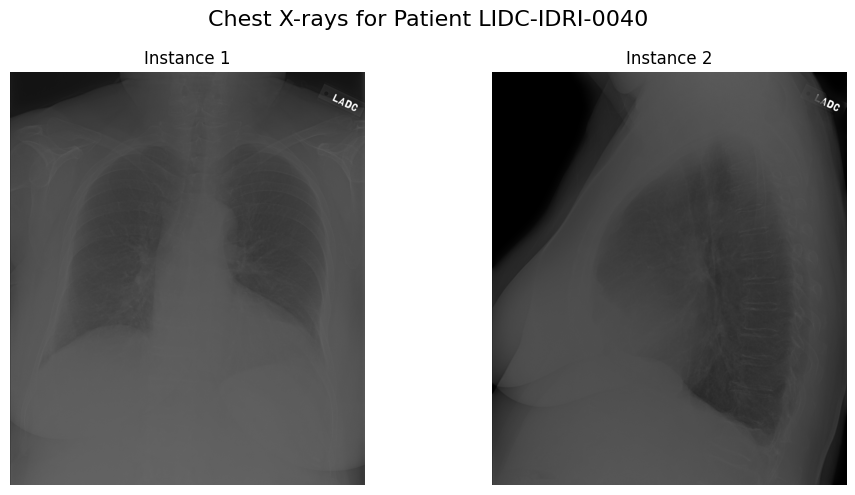

In [52]:
visualize_patient_xrays(
    'LIDC-IDRI-0040',
    dicom_manifest_df
)